In [ ]:
!pip install keras-self-attention

  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18895 sha256=790e7536c5452dd61baa000d46195c9ffb3a2b75ddf45237da45340c67ed4f04
  Stored in directory: /root/.cache/pip/wheels/46/f9/96/709295c836133071c12a300729fed4027757f889c01695feea
Successfully built keras-self-attention


In [ ]:
import numpy as np
import pandas as pd
import re #The re module in Python provides support for pattern matching and text processing.
from bs4 import BeautifulSoup # BeautifulSoup is used for web scraping and parsing HTML/XML data.
from tensorflow.keras.preprocessing.text import Tokenizer # The Tokenizer class is used for converting text into sequences of integers
from keras_self_attention import SeqSelfAttention as AttentionLayer # Implements self-attention mechanisms to help NLP models focus on important words in a sentence.
from keras.preprocessing.sequence import pad_sequences #Padding sequences ensures that input sequences have a uniform length, which is required for training deep learning models
from nltk.corpus import stopwords #Removing stopwords improves model efficiency by focusing on meaningful words.
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed #These are deep learning layers used to build the NLP model.

# Input: Defines the input layer for the model.
# LSTM (Long Short-Term Memory): A recurrent neural network (RNN) layer that is well-suited for text data and sequence modeling.
# Embedding: Converts words into dense vector representations (word embeddings).
# Dense: Fully connected layer for classification or output generation.
# Concatenate: Merges multiple inputs, useful in multi-input NLP models.
# TimeDistributed: Applies a layer (e.g., Dense) to every timestep in a sequence, useful for sequence-to-sequence models.

from tensorflow.keras.models import Model #The Model class is used to create complex deep learning architectures by defining input and output layers.
from tensorflow.keras.callbacks import EarlyStopping #Stops training when the model stops improving to prevent overfitting.
import warnings  #The warnings module is used to suppress unnecessary warnings.

pd.set_option('display.max_colwidth', 200)
warnings.filterwarnings("ignore")


In [ ]:
data = pd.read_csv('/content/Reviews.csv')

In [ ]:
#Drop Duplicates and NA values from datasets
data.drop_duplicates(subset=['Text'], inplace=True)
data.dropna(axis=0, inplace=True)

**Text Pre-processing**

In [ ]:
#Contraction Mapping

contraction_mapping = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

**Pre-processing part:**


1)Convert everything to lowercase


2)Remove HTML tags


3)Contraction mapping


4)Remove (‘s)


5)Remove any text inside the parenthesis ( )


6)Eliminate punctuations and special characters


7)Remove stopwords


8)Remove single characters

In [ ]:
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
stop_words = set(stopwords.words('english'))

def text_cleaner(text,num):

    # lower
    newString = text.lower()

    # remove HTML
    newString = BeautifulSoup(newString, "lxml").text

    # Remove any text inside the parenthesis
    newString = re.sub(r'\([^)]*\)', '', newString)

    # remove double quotes
    newString = re.sub('"','', newString)

    # contraction mapping
    newString = ' '.join([contraction_mapping[t] if t in contraction_mapping else t for t in newString.split(" ")])

    # remove 's
    newString = re.sub(r"'s\b","",newString)

    # Eliminate punctuations and special characters
    newString = re.sub("[^a-zA-Z]", " ", newString)

    # Remove stopwords
    if(num==0):
        tokens = [w for w in newString.split() if not w in stop_words]
    else:
        tokens=newString.split()
    long_words=[]


    # Remove short words
    for i in tokens:
        if len(i)>1:
            long_words.append(i)
    return (" ".join(long_words)).strip()

In [ ]:
#Cleaning the 'Text' column
cleaned_text = []

for t in data['Text']:
  cleaned_text.append(text_cleaner(t, 0))

In [ ]:
cleaned_text[:2]

['bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better',
 'product arrived labeled jumbo salted peanuts peanuts actually small sized unsalted sure error vendor intended represent product jumbo']

In [ ]:
#Cleaning the summary Column
cleaned_summary = []

for t in data['Summary']:
  cleaned_summary.append(text_cleaner(t, 1))

In [ ]:
cleaned_summary[:2]

['good quality dog food', 'not as advertised']

In [ ]:
data['cleaned_text']=cleaned_text
data['cleaned_summary']=cleaned_summary

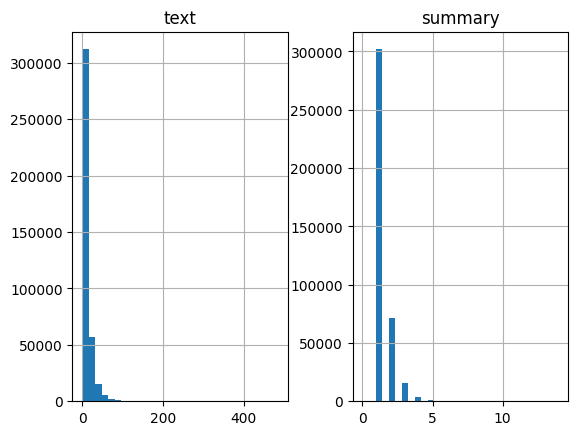

In [ ]:
import matplotlib.pyplot as plt

text_word_count = []
summary_word_count = []

for i in data['cleaned_text']:
  text_word_count.append(len(i.split()))

for i in data['cleaned_summary']:
  summary_word_count.append(len(i.split()))


length_df = pd.DataFrame({'text':text_word_count, 'summary':summary_word_count})

length_df.hist(bins = 30)
plt.show()

In [ ]:
cnt = 0
for i in data['cleaned_summary']:
  if (len(i.split()) <= 8):
    cnt += 1

print(cnt / len(data['cleaned_summary']))

0.9999593454619372


In [ ]:
cnt = 0
for i in data['cleaned_text']:
  if (len(i.split()) <= 30):
    cnt += 1

print(cnt / len(data[cleaned_text]))

In [ ]:
#Let us fix maximum length of review to 30

max_text_len = 30
max_summary_len = 8

In [ ]:
cleaned_text =np.array(data['cleaned_text'])
cleaned_summary=np.array(data['cleaned_summary'])

short_text=[]
short_summary=[]

for i in range(len(cleaned_text)):
    if(len(cleaned_summary[i].split())<=max_summary_len and len(cleaned_text[i].split())<=max_text_len):
        short_text.append(cleaned_text[i])
        short_summary.append(cleaned_summary[i])

df=pd.DataFrame({'text':short_text,'summary':short_summary}) # new dataframe to use

In [ ]:
df['summary'] = df['summary'].apply(lambda x: 'sostok' + x + ' eostok')
df.head()

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(np.array(df['text']), np.array[df['summary']],
                                                    test_size=0.1, random_state=42, shuffle=True)

**Prepare the Tokenizer**

In [ ]:
# A tokenizer builds the vocabulary and converts a word sequence to an integer sequence.
# We will now build tokenizers for text and summary.

x_tokenizer = Tokenizer()
x_tokenizer.fit_on_texts(list(X_train))

In [ ]:
thresh=4

cnt=0
tot_cnt=0
freq=0
tot_freq=0

for key,value in x_tokenizer.word_counts.items():
    tot_cnt=tot_cnt+1
    tot_freq=tot_freq+value
    if(value<thresh):
        cnt=cnt+1
        freq=freq+value

print("% of rare words in vocabulary:", (cnt/tot_cnt)*100)
print("Total Coverage of rare words:", (freq/tot_freq)*100)

NameError: name 'x_tokenizer' is not defined

In [ ]:
print(cnt), print(tot_cnt)

In [ ]:
print(freq), print(tot_freq)

In [ ]:
#prepare a tokenizer for reviews on training data

x_tokenizer = Tokenizer(num_words=tot_cnt - cnt)
x_tokenizer.fit_on_texts(list(X_train))

#Convert text sequences into integer sequences
x_tr_seq = x_tokenizer.texts_to_sequence(X_train)
x_val_seq = x_tokenizer.texts_to_sequence(X_val)

#padding zero upto maximum length
x_tr = pad_sequences(x_tr_seq,  maxlen=max_text_len, padding='post')
x_val = pad_sequences(x_val_seq, maxlen=max_text_len, padding='post')

#Size of vocabulary (+1 for padding token)
x_voc   =  x_tokenizer.num_words + 1

NameError: name 'Tokenizer' is not defined

In [ ]:
ind = []

for i in range(len(y_train)):
  cnt = 0
  for j in y_train[i]:
    if j != 0:
      cnt = cnt + 1

  if (cnt == 2):
    ind.append(i)

y_val=np.delete(y_val,ind, axis=0)
x_val=np.delete(x_val,ind, axis=0)

In [ ]:
ind=[]
for i in range(len(y_val)):
    cnt=0
    for j in y_val[i]:
        if j!=0:
            cnt=cnt+1
    if(cnt==2):
        ind.append(i)

y_val=np.delete(y_val,ind, axis=0)
x_val=np.delete(x_val,ind, axis=0)

In [ ]:
latent_dim = 300
embedding_dim = 100

#Encoder
encoder_inputs = Input(shape=(max_text_len))

#embedding layer
enc_emb = Embedding(x_voc, embedding_dim, trainable=True)(encoder_inputs)

#encoder LSTM 1
encoder_lstm1 = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)
encoder_output1, state_h1, state_c1 = encoder_lstm1(enc_emb)

#encoder LSTM 2
encoder_lstm2 = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.4, recurrent_constraint=0.4)
encoder_output2, state_h2, state_c2 = encoder_lstm2(encoder_output1)

#enocder LSTM 3
encoder_lstm3 = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.4, recurrent_constraint=0.4)
encoder_outputs, state_h, state_c = encoder_lstm3(encoder_output2)



NameError: name 'max_text_len' is not defined

In [ ]:
#Set up the decoder using encdor_states initial state
decoder_inputs = Input(shape=(None, ))

#Embedding layer
dec_emb_layer = Embedding(y_voc, embedding_dim, trainable=True)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)
decoder_outputs,decoder_fwd_state, decoder_back_state = decoder_lstm(dec_emb,initial_state=[state_h, state_c])


#Attention layer
attn_layer = AttentionLayer(name='attention_layer')
attn_out, attn_states = attn_layer([encoder_outputs, decoder_outputs])

#Concat attention input and decoder LSTM output
decoder_concat_input = Concatenate(axis=-1, name='concat_layer')([decoder_outputs, attn_out])

#Dense layer
decoder_dense =  TimeDistributed(Dense(y_voc, activation='softmax'))
decoder_outputs = decoder_dense(decode)

#Define the model
model = Model([encoder, decoder_inputs], decoder_outputs)

model.summary()

In [ ]:
model.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy'
)

In [ ]:
#EarlyStopping monitors the validation loss (val_loss). Our model will stop training once the validation loss increases.

es = EarlyStopping(monitor='val_loss', mode='min', vrebose=1, patience=2)

In [ ]:
history=model.fit([
                  X_train, y_train[:,:-1]],
                  y_train.reshape(y_train.shape[0], y_train.shape[1], 1)[:,1:],
                  epochs=50,
                  callbacks=[es],
                  batch_size=128,
                  validation_data=([x_val,y_val[:,:-1]], y_val.reshape(y_val.shape[0],y_val.shape[1], 1)[:,1:])
                 )

In [ ]:
from matplotlib import pyplot
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

In [ ]:
reverse_target_word_index = y_tokenizer.index_word
reverse_source_word_index = x_tokenizer.index_word
target_word_index = y_tokenizer.word_index

**Inference**

In [ ]:
#Encode the input sequence to get the feature vector
encoder_model = Model(encoder_inputsm outputs=[encoder_outputs, state_h, state_c])

#Decoder setup
#Below tensors will hold the states of previous time step
decoder_state_input_h = Input(shape=(latent_dim, ))
decoder_state_input_c = Input(shape=(latent_dim, ))
decoder_state_input = Input(shape=(max_text_len, latent_dim))


#Get the embeddings of decoder sequence
dec_emb2 = dec_emb_layer(decoder_inputs)

#To predict the next word in the sequence set the initial states ti the state
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c])


#attention inference
attn_out_inf, attn_states_inf = attn_layer([decoder_hidden_state_input, decoder_outputs2])
decoder_inf_concat = Concatenate(axis=-1, name='concat')([decoder_outputs2, attn_out_inf])

#A dense softmax layer to generate prob dist. over the target vocablury
decoder_outputs2 = decoder_dense(decoder_inf_concat)

#Final decoder model
decoder_model = Model(
    [decoder_inputs] + [decoder_hidden_state_input,decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2]
)



In [ ]:
def decode_sequence(input_seq):
    # Encode the input as state vectors.
    e_out, e_h, e_c = encoder_model.predict(input_seq)

    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1,1))

    # Populate the first word of target sequence with the start word.
    target_seq[0, 0] = target_word_index['sostok']

    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:

        output_tokens, h, c = decoder_model.predict([target_seq] + [e_out, e_h, e_c])

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = reverse_target_word_index[sampled_token_index]

        if(sampled_token!='eostok'):
            decoded_sentence += ' '+sampled_token

        # Exit condition: either hit max length or find stop word.
        if (sampled_token == 'eostok'  or len(decoded_sentence.split()) >= (max_summary_len-1)):
            stop_condition = True

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index

        # Update internal states
        e_h, e_c = h, c

    return decoded_sentence

"""
?????????????????????????????????????????????????????
"""

"""
????????????????????????????????????????????????????
"""


In [ ]:
def seq2summary(input_seq):
    newString=''
    for i in input_seq:
        if((i!=0 and i!=target_word_index['sostok']) and i!=target_word_index['eostok']):
            newString=newString+reverse_target_word_index[i]+' '
    return newString

def seq2text(input_seq):
    newString=''
    for i in input_seq:
        if(i!=0):
            newString=newString+reverse_source_word_index[i]+' '
    return newString

In [ ]:
for i in range(0, 10):
    print("Review:",seq2text(x_tr[i]))
    print("Original summary:",seq2summary(y_tr[i]))
    print("Predicted summary:",decode_sequence(x_tr[i].reshape(1,max_text_len)))
    print("\n")

**Text Summarization using Transformers**

In [ ]:
from transformers import pipeline

In [ ]:
import bs4 as bs
import urllib.request
import re

In [ ]:
scraped_data = urllib.request.urlopen('https://en.wikipedia.org/wiki/Artificial_intelligence')
article = scraped_data.read()
parsed_article = bs.BeautifulSoup(article,'lxml')
paragraphs = parsed_article.find_all('p')

In [ ]:
article_text = ""
for p in paragraphs:
    article_text += p.text

In [ ]:
article_text[0:500]

'\nArtificial intelligence (AI) refers to the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.[1] Such machines may be call'

In [ ]:
#Text preprocessing

#Removing Square Brackets and Extra Spaces
article_text = re.sub(r'\[[0-9]*\]', ' ', article_text)
article_text = re.sub(r'\s+', ' ', article_text)

In [ ]:
# Removing special characters and digits
formatted_article_text = re.sub('[^a-zA-Z]', ' ', article_text )
formatted_article_text = re.sub(r'\s+', ' ', formatted_article_text)

In [ ]:
len(formatted_article_text)


80656

In [ ]:
formatted_article_text_1 = formatted_article_text[0:500]

In [ ]:
summarizer1 = pipeline(
    'summarization',
    model='t5-base',
    tokenizer='t5-base',
    framework='tf'
)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFT5ForConditionalGeneration.

All the weights of TFT5ForConditionalGeneration were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFT5ForConditionalGeneration for predictions without further training.


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Device set to use 0


In [ ]:
formatted_article_text_1

' Artificial intelligence AI refers to the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem solving perception and decision making It is a field of research in computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals Such machines may be called AIs High '

In [ ]:
summarizer1(
    formatted_article_text_1,
    min_length=5,
    max_length=500,
    do_sample=False
)

Your max_length is set to 500, but your input_length is only 82. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=41)


[{'summary_text': 'artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem solving perception and decision making . it is a field of research in computer science that develops and studies methods and software that enable machines to perceive their environment .'}]

In [ ]:
summarizer1(formatted_article_text_1, min_length=5, max_length=20,do_sample=False)


[{'summary_text': 'artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence'}]

In [ ]:
text_string = data.Text[0]
text_string

NameError: name 'data' is not defined

In [ ]:
summarizer1(text_string, min_length=5, max_length=20, do_sample=False)

NameError: name 'text_string' is not defined